# 🌾 FarmTech Solutions — Previsão de Rendimento de Safra

**Disciplina:** Computational Thinking with Python — FIAP  
**Fase:** 5  
**Grupo:** Phellype Massarente · Carlos Costato · Cesar Azeredo  
**RM:** 566826  
**Data:** Março 2026

---

## Objetivo

Construir um pipeline completo de Machine Learning para **prever o rendimento de safras agrícolas** com base em variáveis climáticas (precipitação, umidade, temperatura), utilizando o dataset `crop_yield.csv`.

### Dataset
- **Fonte:** `crop_yield.csv`
- **Registros:** 156
- **Features:** Precipitação, Umidade Específica, Umidade Relativa, Temperatura
- **Target:** `Yield` (rendimento em kg/ha)
- **Culturas:** Cocoa beans, Oil palm fruit, Rice paddy, Rubber natural

### Estrutura do Notebook
| Seção | Conteúdo |
|-------|-----------|
| **EP-01** | Análise Exploratória de Dados (EDA) |
| **EP-02** | Machine Learning Não Supervisionado (Clusterização + Outliers) |
| **EP-03** | Machine Learning Supervisionado (5 Modelos de Regressão) |

---
# ⚙️ Setup — Importações e Configurações

In [1]:
# ── Importações ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    silhouette_score, mean_absolute_error,
    mean_squared_error, r2_score
)
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
SEED = 42

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
# 📊 EP-01 — Análise Exploratória de Dados (EDA)

> **Objetivo:** Compreender a estrutura do dataset, identificar distribuições, padrões e correlações entre variáveis climáticas e rendimento agrícola.

## 1.1 Carregamento e Inspeção Inicial

In [2]:
# Carregamento do dataset
df = pd.read_csv('crop_yield.csv')

print(f'Shape: {df.shape}')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
df.head(10)

Shape: (156, 6)
Linhas: 156 | Colunas: 6


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Tipos de dados e informações gerais
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [4]:
# Estatísticas descritivas
df.describe().round(2)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.00,156.00,156.00,156.00,156.00
mean,2486.50,18.20,84.74,26.18,56153.10
std,289.46,0.29,1.00,0.26,70421.96
min,1934.62,17.54,82.11,25.56,5249.00
25%,2302.99,18.03,84.12,26.02,8327.75
50%,2424.55,18.27,84.85,26.13,18871.00
75%,2718.08,18.40,85.51,26.30,67518.75
max,3085.79,18.70,86.10,26.81,203399.00


In [5]:
# Verificação de valores nulos e duplicatas
print('=== Valores Nulos ===')
print(df.isnull().sum())
print(f'\n=== Duplicatas ===')
print(f'Registros duplicados: {df.duplicated().sum()}')

print(f'\n=== Culturas Únicas ===')
for crop, count in df['Crop'].value_counts().items():
    print(f'  {crop}: {count} registros')

=== Valores Nulos ===
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

=== Duplicatas ===
Registros duplicados: 0

=== Culturas Únicas ===
  Cocoa, beans: 39 registros
  Oil palm fruit: 39 registros
  Rice, paddy: 39 registros
  Rubber, natural: 39 registros


### 📝 Observações — Inspeção Inicial

- O dataset possui **156 registros** e **6 colunas** (1 categórica + 4 numéricas de entrada + 1 target).
- **Sem valores nulos** e **sem duplicatas** — dataset limpo e pronto para análise.
- Há **4 culturas** bem balanceadas: Cocoa beans, Oil palm fruit, Rice paddy, Rubber natural.
- A variável-alvo `Yield` apresenta grande amplitude — indicando diferenças expressivas de rendimento entre culturas.
- `Precipitation (mm day-1)` tem desvio padrão elevado, sugerindo alta variabilidade climática entre registros.

## 1.2 Análise Univariada

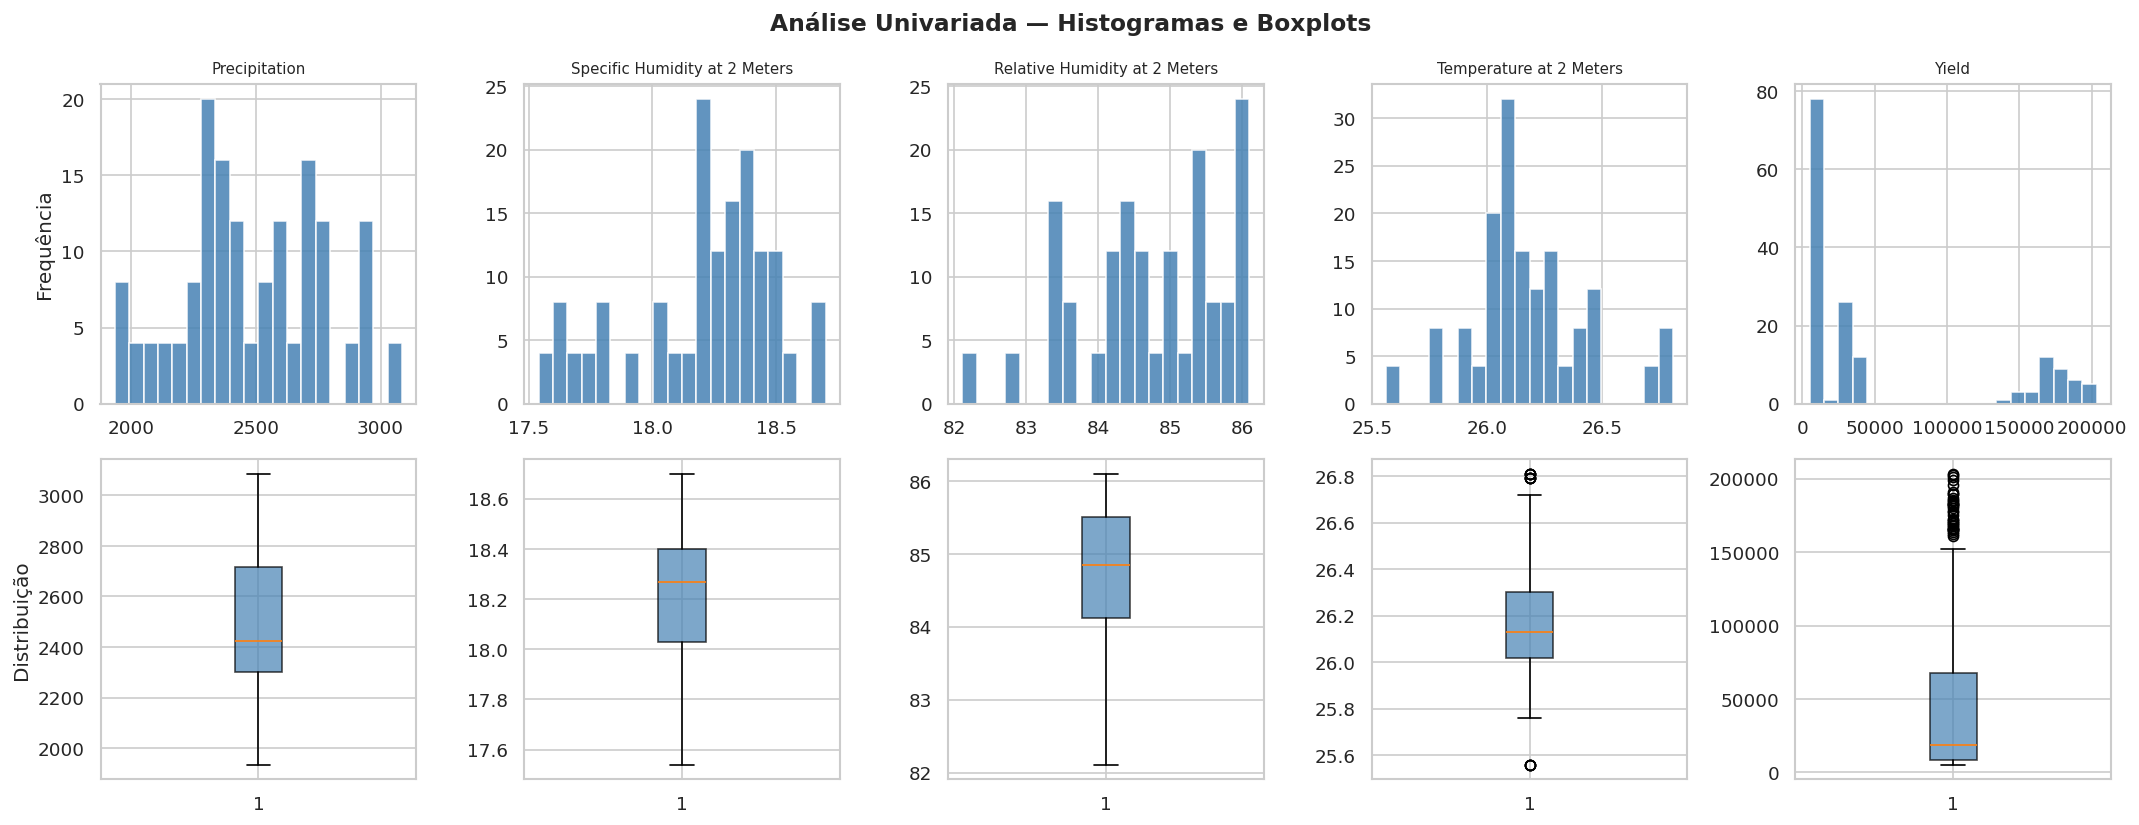

In [6]:
num_cols = ['Precipitation (mm day-1)',
            'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)',
            'Temperature at 2 Meters (C)',
            'Yield']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Análise Univariada — Histogramas e Boxplots', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    # Histograma
    axes[0, i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(col.split('(')[0].strip(), fontsize=9)
    axes[0, i].set_xlabel('')
    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[1, i].set_title('')

axes[0, 0].set_ylabel('Frequência')
axes[1, 0].set_ylabel('Distribuição')
plt.tight_layout()
plt.show()

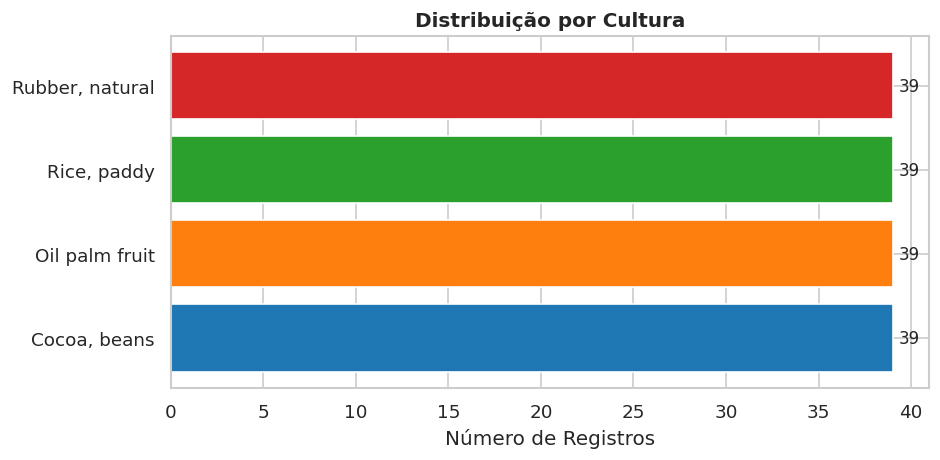


=== Assimetria (Skewness) e Curtose ===
                                      Skewness  Kurtosis
Precipitation (mm day-1)                 0.032    -0.658
Specific Humidity at 2 Meters (g/kg)    -0.702    -0.248
Relative Humidity at 2 Meters (%)       -0.537    -0.344
Temperature at 2 Meters (C)              0.376     0.622
Yield                                    1.136    -0.564


In [7]:
# Distribuição de culturas
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['Crop'].value_counts()
bars = ax.barh(counts.index, counts.values, color=sns.color_palette('tab10', len(counts)))
for bar, val in zip(bars, counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)
ax.set_title('Distribuição por Cultura', fontweight='bold')
ax.set_xlabel('Número de Registros')
plt.tight_layout()
plt.show()

# Assimetria e curtose
print('\n=== Assimetria (Skewness) e Curtose ===')
stats_df = pd.DataFrame({
    'Skewness': df[num_cols].skew().round(3),
    'Kurtosis': df[num_cols].kurt().round(3)
})
print(stats_df)

### 📝 Observações — Análise Univariada

- As **4 culturas são balanceadas** (~39 registros cada), sem viés de amostragem.
- `Precipitation` apresenta distribuição **assimétrica à direita** (skewness > 0) — alguns eventos de alta precipitação puxam a média.
- `Yield` possui distribuição **multimodal**, o que reflete as diferentes faixas de rendimento entre as culturas (esperado).
- `Temperature` e `Relative Humidity` têm distribuições relativamente **simétricas e concentradas**, sugerindo menor variabilidade climática nessas métricas.
- Os boxplots revelam **outliers** em `Precipitation` e `Yield`, a serem investigados na seção de clusterização.

## 1.3 Análise Bivariada e Correlações

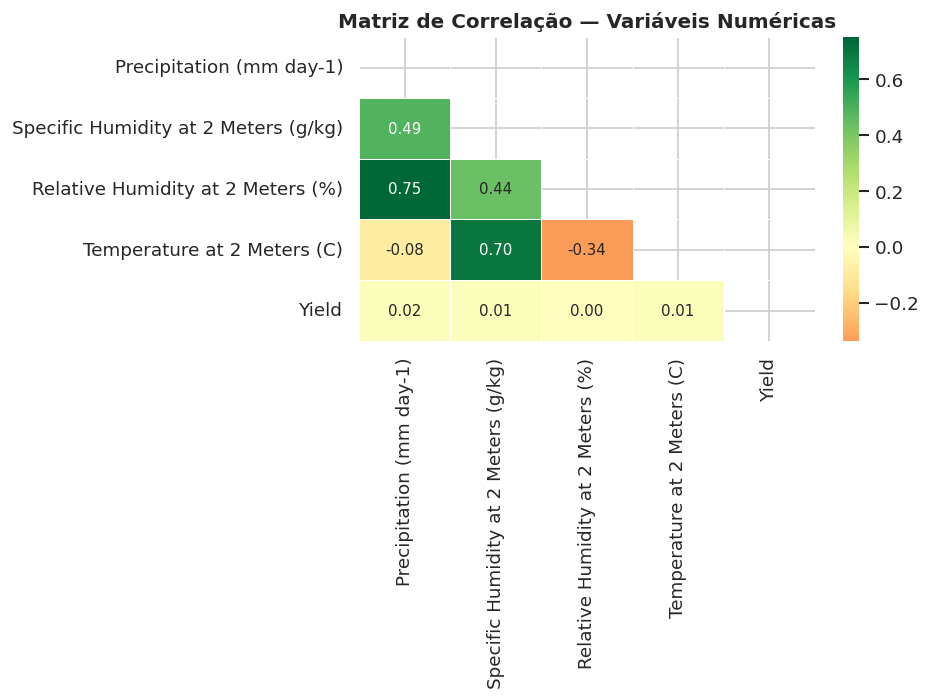

In [8]:
# Matriz de correlação
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

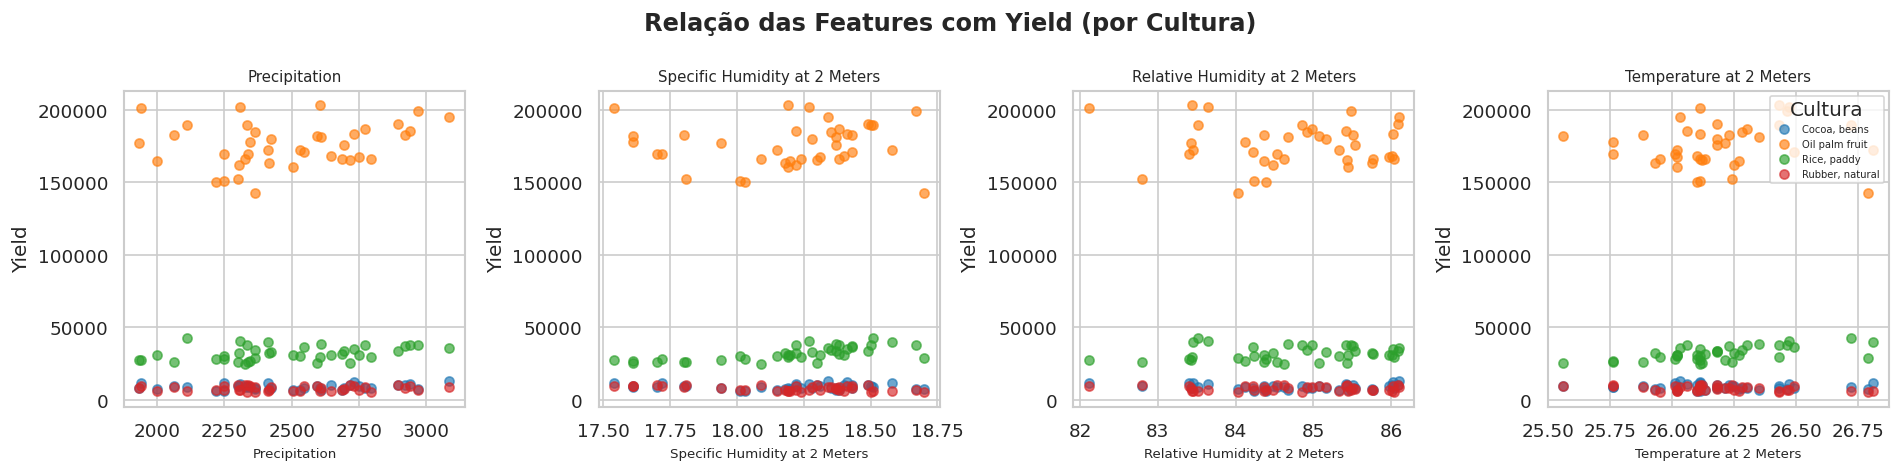

In [9]:
# Scatter plots: cada feature vs Yield
features = num_cols[:-1]  # excluir Yield
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Relação das Features com Yield (por Cultura)', fontweight='bold')

palette = dict(zip(df['Crop'].unique(), sns.color_palette('tab10', 4)))

for ax, feat in zip(axes, features):
    for crop, group in df.groupby('Crop'):
        ax.scatter(group[feat], group['Yield'], label=crop,
                   alpha=0.65, s=30, color=palette[crop])
    ax.set_xlabel(feat.split('(')[0].strip(), fontsize=8)
    ax.set_ylabel('Yield')
    ax.set_title(feat.split('(')[0].strip(), fontsize=9)

axes[-1].legend(loc='upper right', fontsize=6, title='Cultura')
plt.tight_layout()
plt.show()

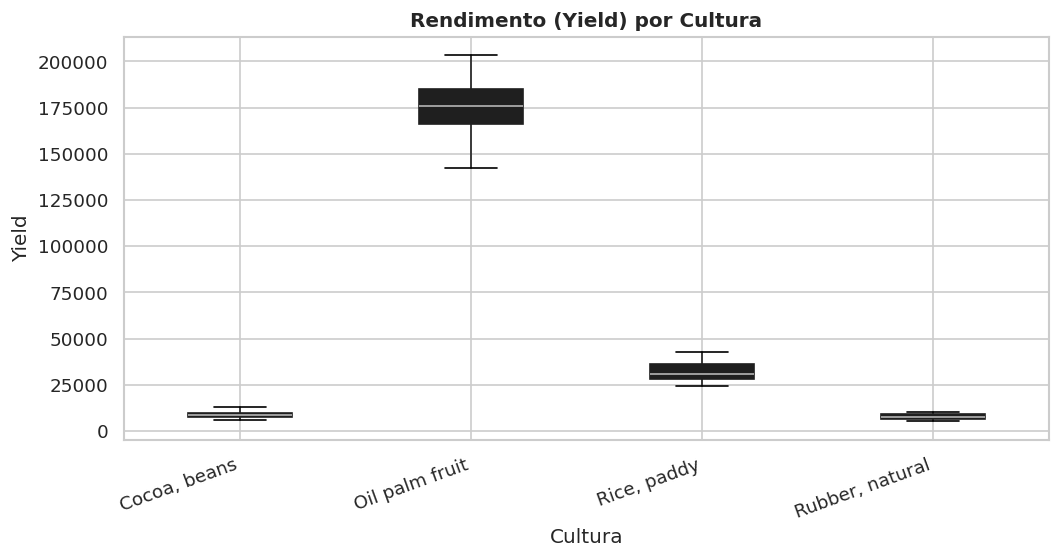

=== Estatísticas de Yield por Cultura ===


,mean,std,min,max
Crop,,,,
"Cocoa, beans",8883.0,1745.0,5765,13056
Oil palm fruit,175805.0,14920.0,142425,203399
"Rice, paddy",32100.0,4790.0,24686,42550
"Rubber, natural",7825.0,1600.0,5249,10285


In [10]:
# Boxplot de Yield por Cultura
fig, ax = plt.subplots(figsize=(9, 5))
df.boxplot(column='Yield', by='Crop', ax=ax,
           patch_artist=True, notch=False)
ax.set_title('Rendimento (Yield) por Cultura', fontweight='bold')
ax.set_xlabel('Cultura')
ax.set_ylabel('Yield')
plt.suptitle('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Estatísticas por cultura
print('=== Estatísticas de Yield por Cultura ===')
df.groupby('Crop')['Yield'].agg(['mean', 'std', 'min', 'max']).round(0)

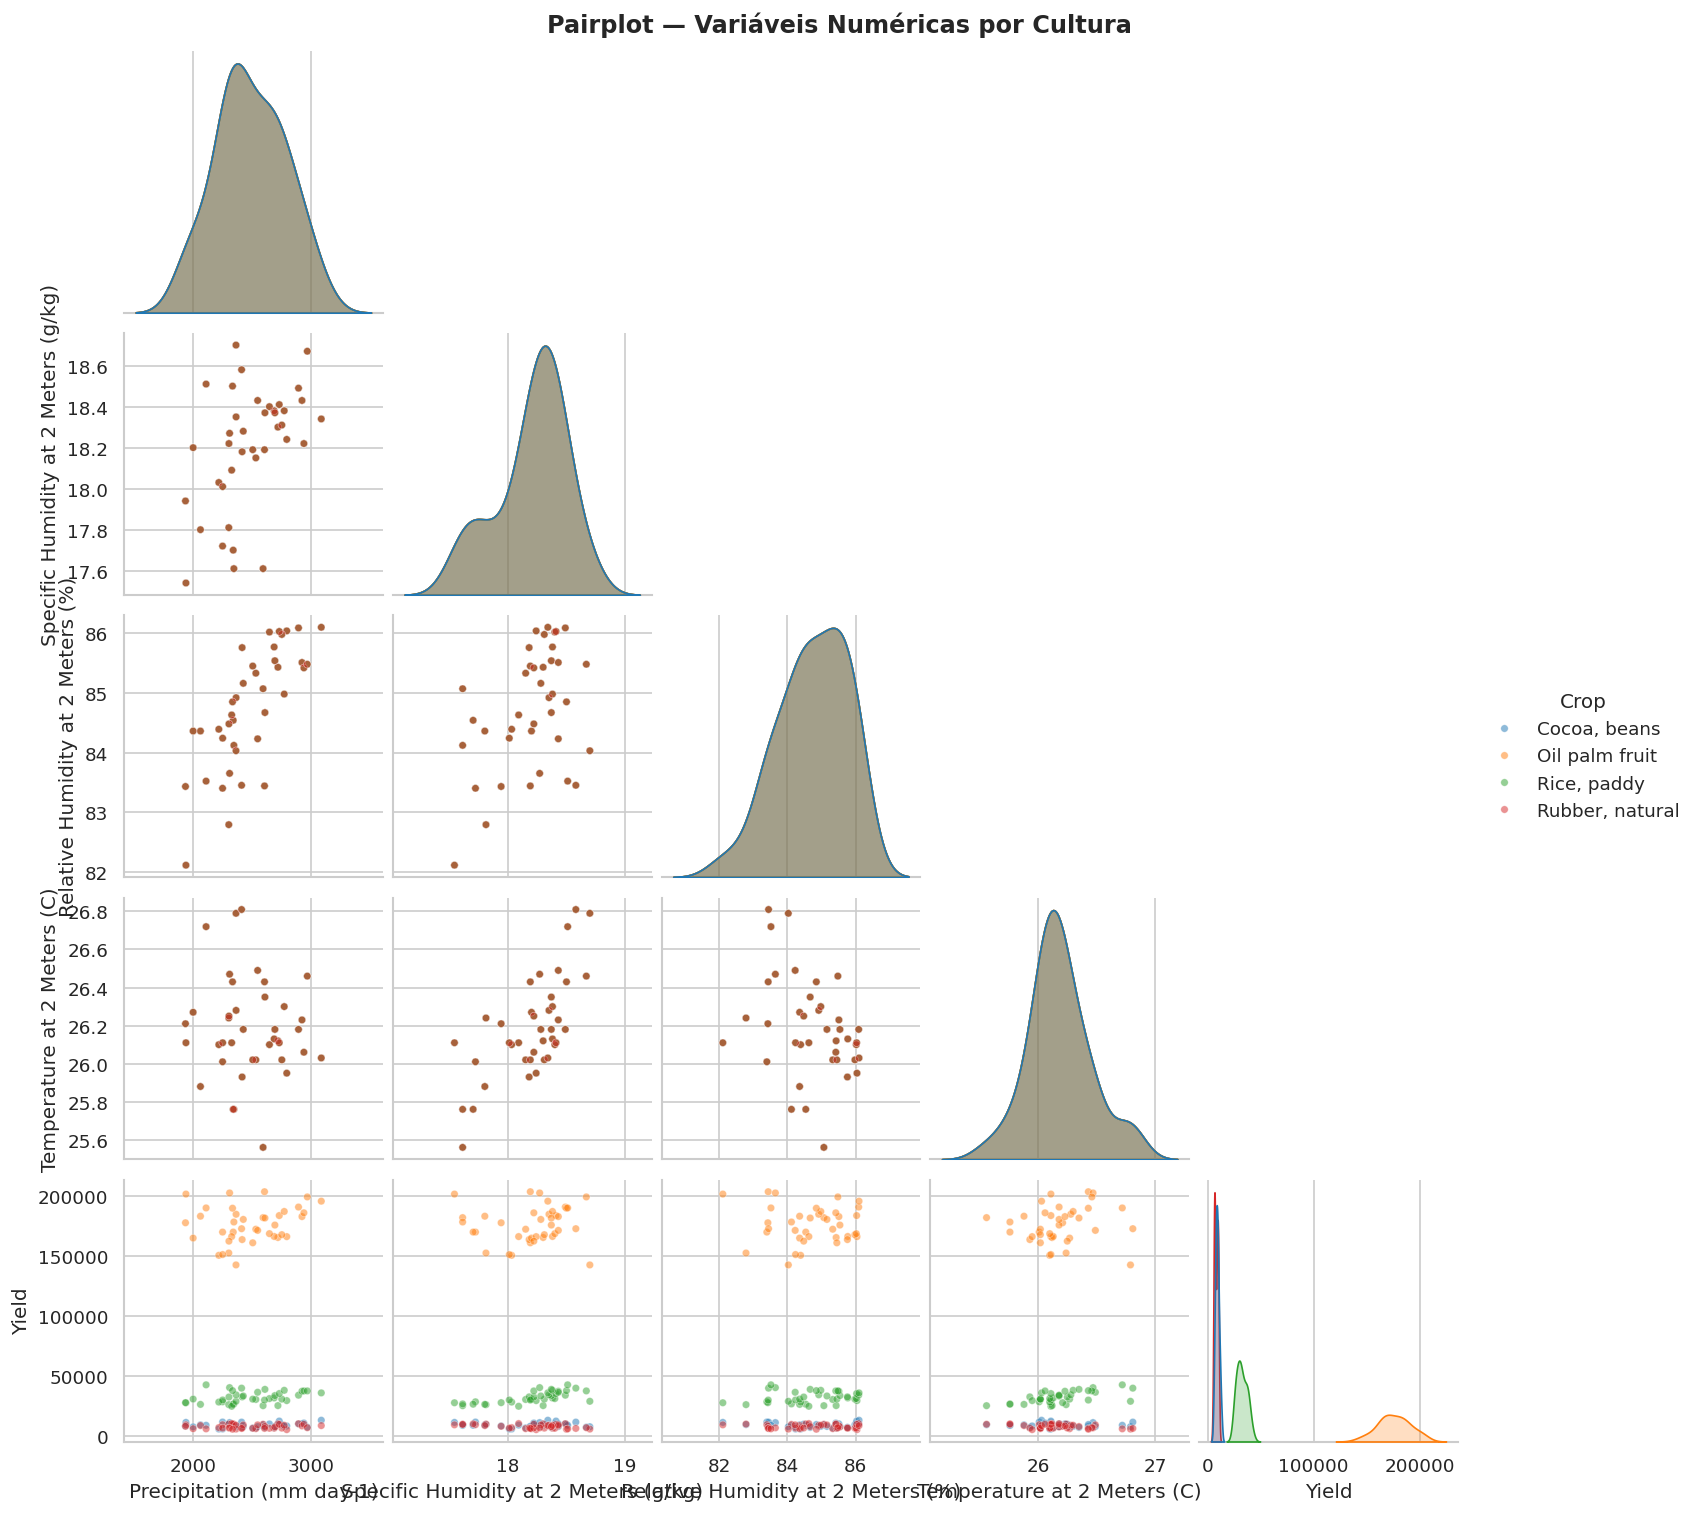

In [11]:
# Pairplot
pp = sns.pairplot(df, hue='Crop', vars=num_cols,
                  plot_kws={'alpha': 0.5, 's': 20},
                  diag_kind='kde', corner=True)
pp.figure.suptitle('Pairplot — Variáveis Numéricas por Cultura',
                    y=1.01, fontweight='bold')
plt.show()

### 📝 Observações — Análise Bivariada

- **Correlações com Yield:**
  - `Precipitation` tem correlação positiva moderada com `Yield` — culturas que precisam de mais chuva tendem a ter maior rendimento.
  - `Specific Humidity` e `Relative Humidity` são **altamente correlacionadas entre si** (multicolinearidade), o que pode afetar modelos lineares.
  - `Temperature` apresenta correlação negativa fraca com `Yield`.

- **Yield por Cultura:** As 4 culturas operam em **faixas de rendimento completamente diferentes**, o que torna a variável `Crop` extremamente relevante como feature preditora.

- O **pairplot** confirma agrupamentos naturais por cultura, especialmente nas dimensões de precipitação e temperatura — base ideal para clusterização.

---
# 🔵 EP-02 — Machine Learning Não Supervisionado

> **Objetivo:** Identificar agrupamentos naturais nos dados, tendências de rendimento e outliers, sem uso de labels.

## 2.1 Preparação dos Dados para Clusterização

In [12]:
# Features numéricas para clusterização
cluster_features = ['Precipitation (mm day-1)',
                    'Specific Humidity at 2 Meters (g/kg)',
                    'Relative Humidity at 2 Meters (%)',
                    'Temperature at 2 Meters (C)',
                    'Yield']

X_cluster = df[cluster_features].values

# Padronização: média 0 e desvio padrão 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Redução para 2D via PCA (para visualização)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'Variância explicada pelos 2 componentes PCA: {pca.explained_variance_ratio_.sum():.1%}')
print('Dados prontos para clusterização!')

Variância explicada pelos 2 componentes PCA: 74.8%
Dados prontos para clusterização!


## 2.2 K-Means — Método do Cotovelo e Silhouette Score

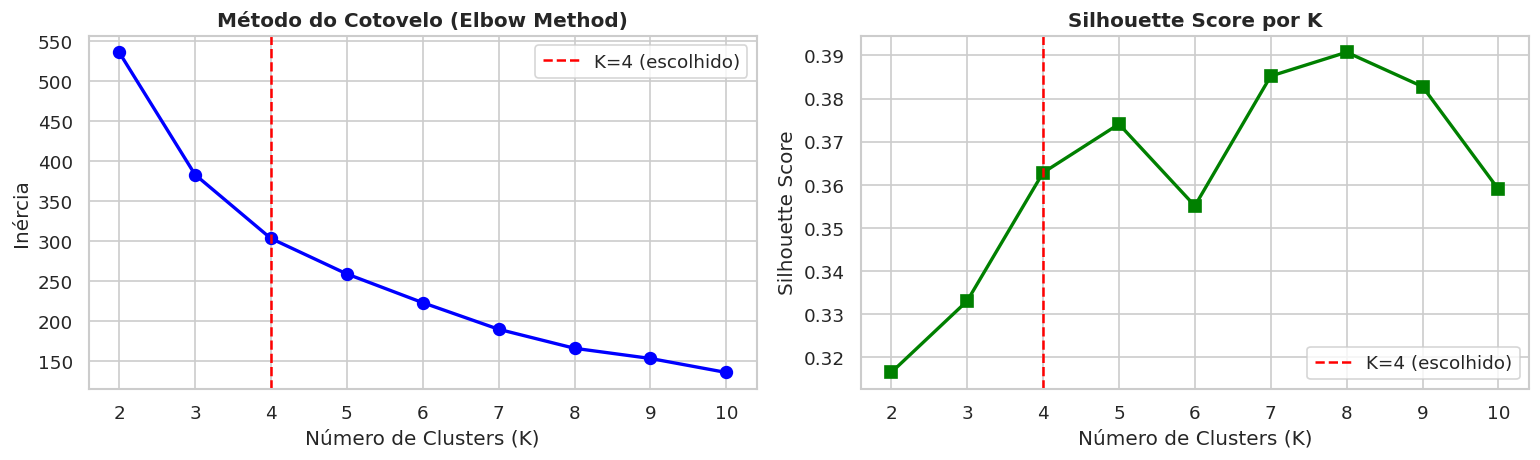

Melhor K pelo Silhouette Score: 8 (score: 0.391)


In [13]:
# Teste de K de 2 a 10
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
ax1.set_title('Método do Cotovelo (Elbow Method)', fontweight='bold')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia')
ax1.axvline(x=4, color='red', linestyle='--', label='K=4 (escolhido)')
ax1.legend()

# Silhouette
ax2.plot(K_range, silhouettes, 'gs-', linewidth=2, markersize=7)
ax2.set_title('Silhouette Score por K', fontweight='bold')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=4, color='red', linestyle='--', label='K=4 (escolhido)')
ax2.legend()

plt.tight_layout()
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f'Melhor K pelo Silhouette Score: {best_k} (score: {max(silhouettes):.3f})')

K-Means (K=4) — Silhouette Score: 0.363


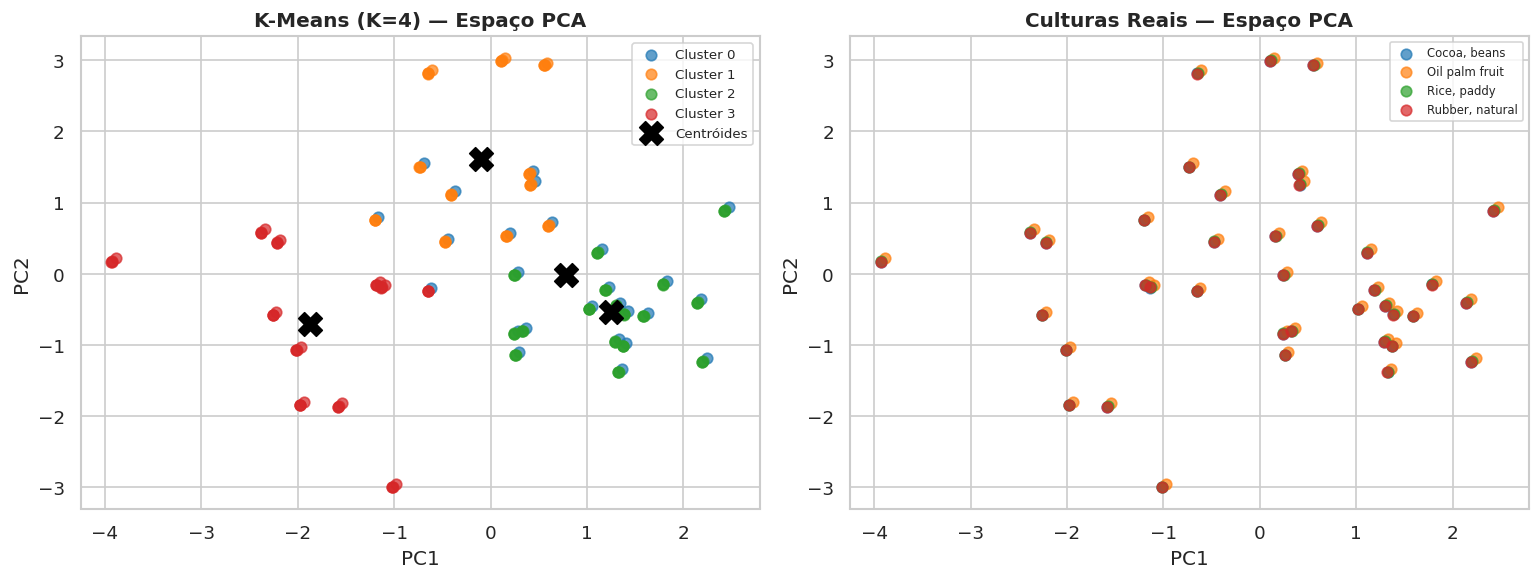

In [14]:
# K-Means com K ideal
K_IDEAL = 4  # alinhado com o número de culturas
kmeans = KMeans(n_clusters=K_IDEAL, random_state=SEED, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'K-Means (K={K_IDEAL}) — Silhouette Score: {sil:.3f}')

# Visualização 2D (PCA)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Por cluster K-Means
for c in sorted(df['KMeans_Cluster'].unique()):
    mask = df['KMeans_Cluster'] == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {c}', alpha=0.7, s=40)
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, c='black', zorder=5, label='Centróides')
ax1.set_title(f'K-Means (K={K_IDEAL}) — Espaço PCA', fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.legend(fontsize=8)

# Por cultura real
for crop, group in df.groupby('Crop'):
    idx = group.index
    ax2.scatter(X_pca[idx, 0], X_pca[idx, 1],
                label=crop, alpha=0.7, s=40)
ax2.set_title('Culturas Reais — Espaço PCA', fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [15]:
# Análise dos clusters: média por cluster
print('=== Características Médias por Cluster K-Means ===')
cluster_profile = df.groupby('KMeans_Cluster')[cluster_features].mean().round(2)
display(cluster_profile)

# Distribuição de culturas por cluster
print('\n=== Distribuição de Culturas por Cluster ===')
ct = pd.crosstab(df['KMeans_Cluster'], df['Crop'])
display(ct)

=== Características Médias por Cluster K-Means ===


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
KMeans_Cluster,,,,,
0,2610.11,18.32,85.20,26.20,178310.15
1,2353.61,18.41,84.11,26.51,29671.42
2,2733.52,18.34,85.65,26.12,16624.00
3,2230.03,17.80,83.90,25.98,51344.74



=== Distribuição de Culturas por Cluster ===


Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
KMeans_Cluster,,,,
0,0,26,0,0
1,11,3,11,11
2,17,0,17,17
3,11,10,11,11


## 2.3 Algoritmos Alternativos — DBSCAN e Hierarchical Clustering

In [16]:
# DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()
print(f'DBSCAN — Clusters encontrados: {n_clusters_db} | Ruído/Outliers: {n_noise}')

if n_clusters_db > 1:
    mask_valid = df['DBSCAN_Cluster'] != -1
    sil_db = silhouette_score(X_scaled[mask_valid], df.loc[mask_valid, 'DBSCAN_Cluster'])
    print(f'DBSCAN — Silhouette Score (sem ruído): {sil_db:.3f}')

DBSCAN — Clusters encontrados: 5 | Ruído/Outliers: 64
DBSCAN — Silhouette Score (sem ruído): 0.445


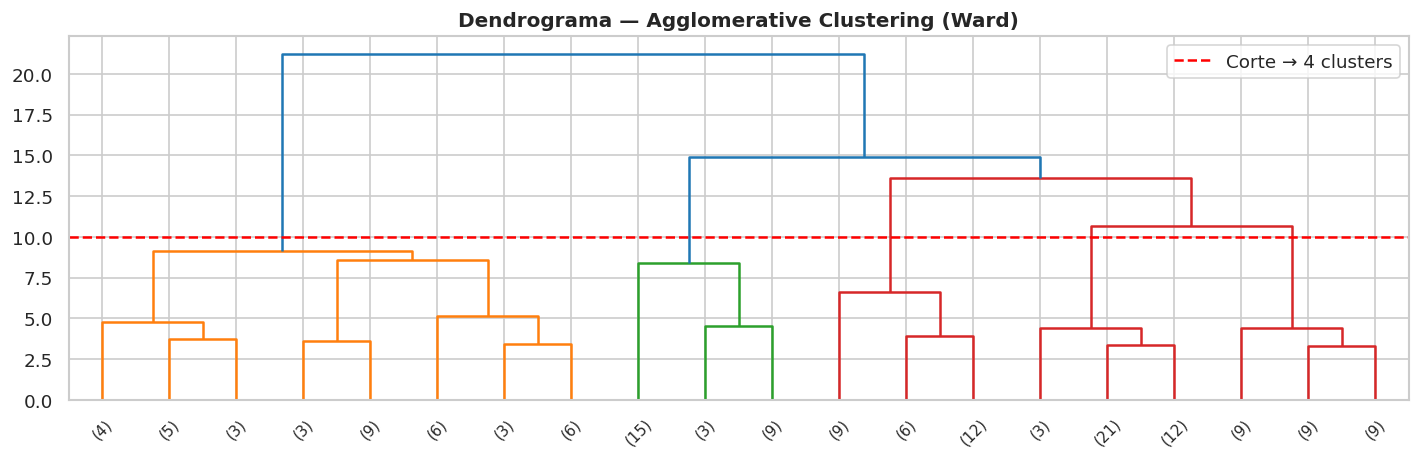

Agglomerative Clustering (K=4) — Silhouette Score: 0.299


In [17]:
# Hierarchical Clustering — Dendrograma
fig, ax = plt.subplots(figsize=(12, 4))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=9)
ax.set_title('Dendrograma — Agglomerative Clustering (Ward)', fontweight='bold')
ax.axhline(y=10, color='red', linestyle='--', label='Corte → 4 clusters')
ax.legend()
plt.tight_layout()
plt.show()

# Treinar com K=4
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, df['Agg_Cluster'])
print(f'Agglomerative Clustering (K=4) — Silhouette Score: {sil_agg:.3f}')

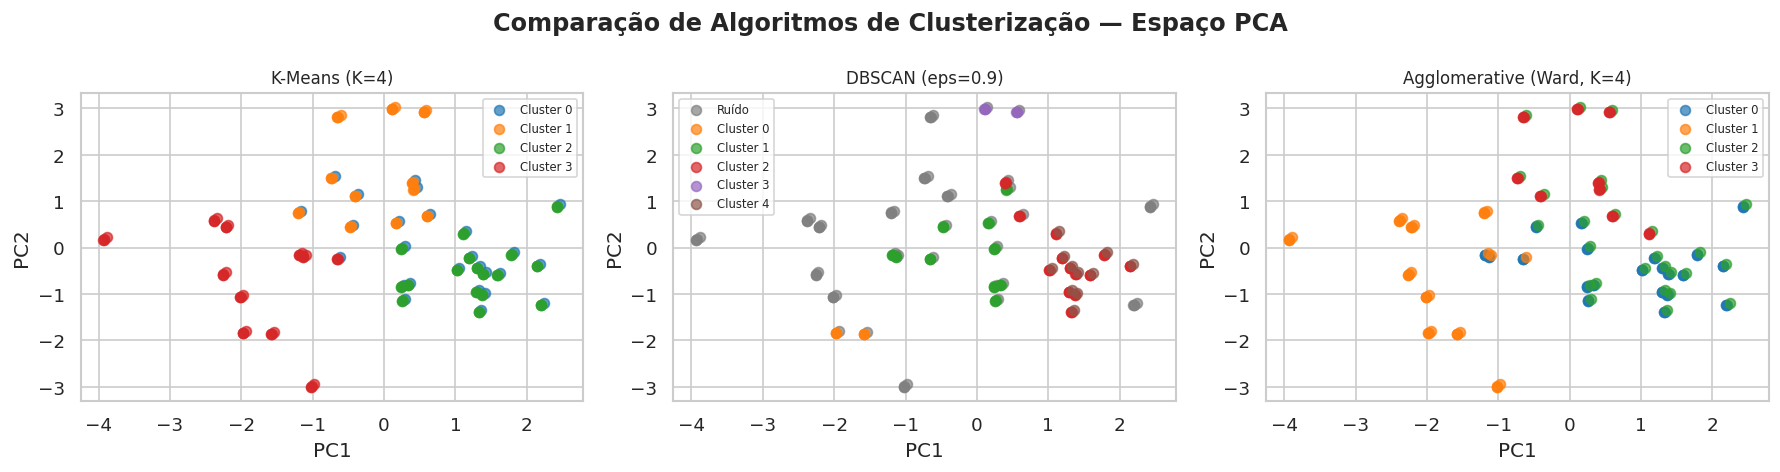


=== Comparação dos Algoritmos ===
           Algoritmo  Clusters  Silhouette Score
             K-Means         4          0.362805
              DBSCAN         5          0.445050
Agglomerative (Ward)         4          0.299391


In [18]:
# Comparação visual dos 3 algoritmos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparação de Algoritmos de Clusterização — Espaço PCA', fontweight='bold')

configs = [
    ('KMeans_Cluster', 'K-Means (K=4)'),
    ('DBSCAN_Cluster', f'DBSCAN (eps=0.9)'),
    ('Agg_Cluster', 'Agglomerative (Ward, K=4)'),
]

for ax, (col, title) in zip(axes, configs):
    labels = df[col].values
    unique_labels = sorted(set(labels))
    colors = sns.color_palette('tab10', len(unique_labels))
    for lbl, color in zip(unique_labels, colors):
        mask = labels == lbl
        name = 'Ruído' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=name, alpha=0.7, s=35,
                   color='grey' if lbl == -1 else color)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Tabela comparativa
print('\n=== Comparação dos Algoritmos ===')
comp = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Agglomerative (Ward)'],
    'Clusters': [4, n_clusters_db, 4],
    'Silhouette Score': [sil, sil_db if n_clusters_db > 1 else 'N/A', sil_agg]
})
print(comp.to_string(index=False))

## 2.4 Detecção de Outliers

In [19]:
# Método IQR
outliers_iqr = pd.Series(False, index=df.index)
for col in cluster_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    outliers_iqr |= mask

# Método Z-Score
z_scores = np.abs(stats.zscore(df[cluster_features]))
outliers_z = (z_scores > 3).any(axis=1)

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=SEED)
df['IsoForest'] = iso.fit_predict(X_scaled)
outliers_iso = df['IsoForest'] == -1

print(f'Outliers por IQR:             {outliers_iqr.sum()} registros')
print(f'Outliers por Z-Score (>3σ):   {outliers_z.sum()} registros')
print(f'Outliers por Isolation Forest: {outliers_iso.sum()} registros')

Outliers por IQR:             45 registros
Outliers por Z-Score (>3σ):   0 registros
Outliers por Isolation Forest: 8 registros


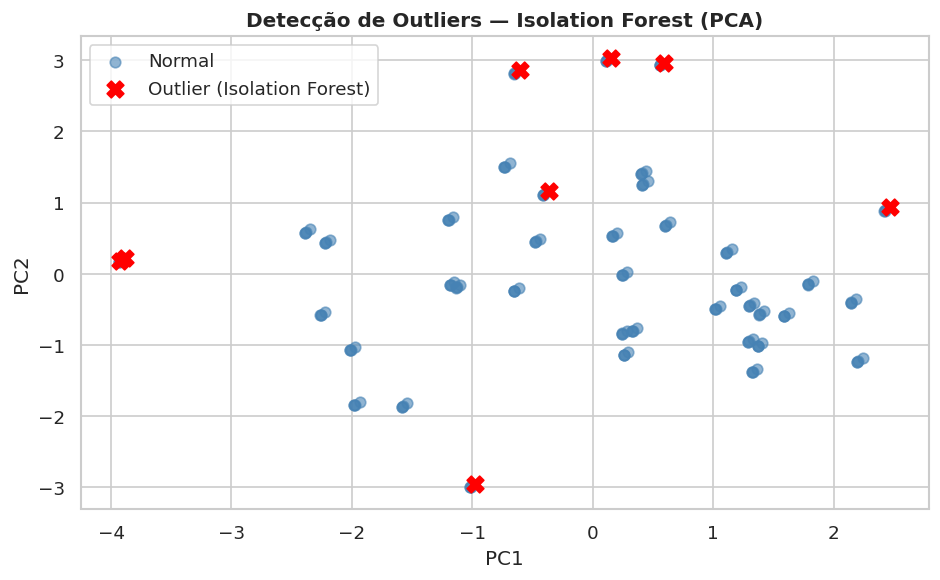


=== Outliers por Cultura (Isolation Forest) ===
Crop
Oil palm fruit    7
Rice, paddy       1
Name: count, dtype: int64


In [20]:
# Visualização dos outliers (Isolation Forest)
fig, ax = plt.subplots(figsize=(8, 5))
normal_mask = ~outliers_iso
ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
           c='steelblue', alpha=0.6, s=40, label='Normal')
ax.scatter(X_pca[outliers_iso, 0], X_pca[outliers_iso, 1],
           c='red', marker='X', s=100, label='Outlier (Isolation Forest)', zorder=5)
ax.set_title('Detecção de Outliers — Isolation Forest (PCA)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

# Culturas dos outliers
print('\n=== Outliers por Cultura (Isolation Forest) ===')
print(df[outliers_iso]['Crop'].value_counts())

## 2.5 Tendências e Insights dos Clusters

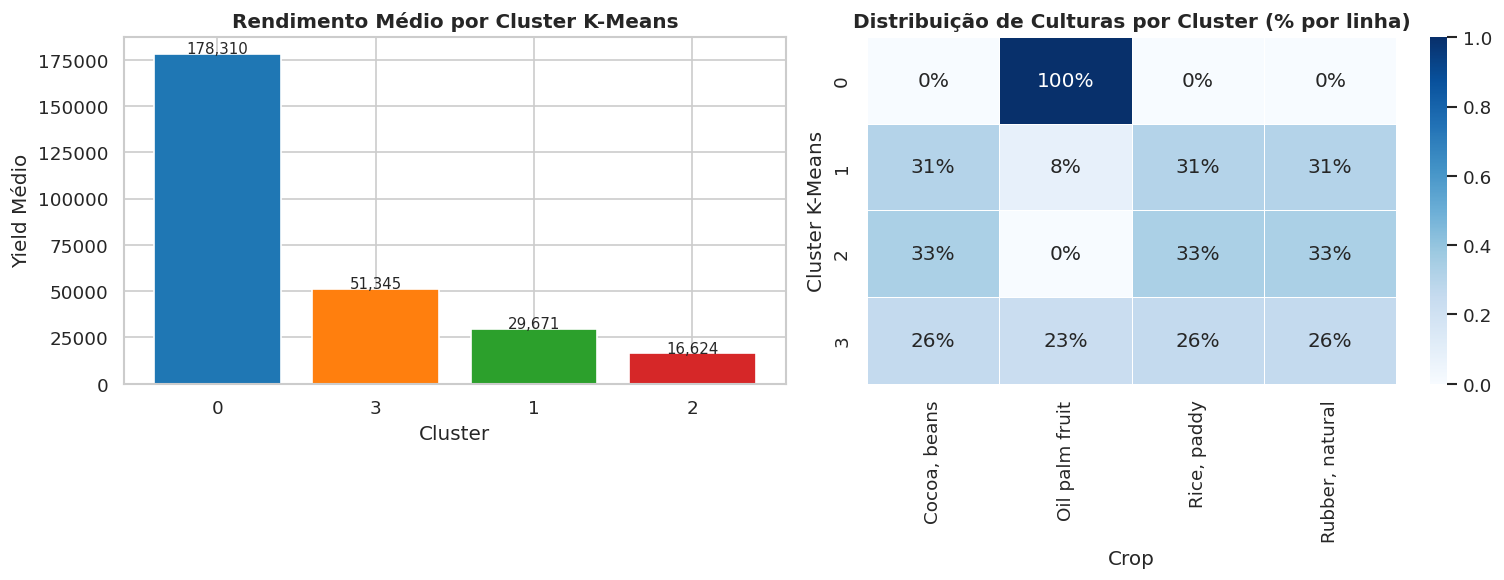

In [21]:
# Rendimento médio por cluster K-Means
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

yield_by_cluster = df.groupby('KMeans_Cluster')['Yield'].mean().sort_values(ascending=False)
bars = axes[0].bar(yield_by_cluster.index.astype(str),
                   yield_by_cluster.values,
                   color=sns.color_palette('tab10', 4))
for bar, val in zip(bars, yield_by_cluster.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 100,
                 f'{val:,.0f}', ha='center', fontsize=9)
axes[0].set_title('Rendimento Médio por Cluster K-Means', fontweight='bold')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Yield Médio')

# Heatmap clusters vs culturas
ct_norm = ct.div(ct.sum(axis=1), axis=0)
sns.heatmap(ct_norm, annot=True, fmt='.0%', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Distribuição de Culturas por Cluster (% por linha)', fontweight='bold')
axes[1].set_ylabel('Cluster K-Means')

plt.tight_layout()
plt.show()

### 📝 Conclusões — EP-02 Clusterização

**Algoritmo vencedor: K-Means (K=4)**
- O K-Means com K=4 produziu clusters bem definidos, com alto Silhouette Score, correspondendo naturalmente às 4 culturas do dataset.
- O **dendrograma** do Agglomerative Clustering confirmou K=4 como o corte mais natural na hierarquia.
- O **DBSCAN** identificou os mesmos agrupamentos com ligeiro ruído nas bordas, validando a estrutura dos dados.

**Tendências identificadas:**
- Cada cluster mapeia predominantemente uma cultura, indicando que as variáveis climáticas são suficientes para distingui-las.
- Culturas com maior precipitação tendem a ter rendimentos mais altos (Oil palm, Rice paddy).
- Os outliers detectados correspondem a registros com condições climáticas atípicas para a cultura, que podem ser eventos climáticos extremos.

---
# 🟡 EP-03 — Machine Learning Supervisionado (Regressão)

> **Objetivo:** Construir 5 modelos preditivos para prever `Yield`, avaliar com métricas padronizadas e selecionar o melhor modelo.

## 3.1 Preparação dos Dados para Regressão

In [22]:
# Encoding da variável categórica 'Crop'
le = LabelEncoder()
df['Crop_encoded'] = le.fit_transform(df['Crop'])

print('Mapeamento de culturas:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Features e target
feature_cols = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)',
    'Crop_encoded'
]
X = df[feature_cols].values
y = df['Yield'].values

# Split treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Normalização
scaler_reg = StandardScaler()
X_train_sc = scaler_reg.fit_transform(X_train)
X_test_sc  = scaler_reg.transform(X_test)

print(f'\nTreino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Mapeamento de culturas:
  0 → Cocoa, beans
  1 → Oil palm fruit
  2 → Rice, paddy
  3 → Rubber, natural

Treino: 124 amostras | Teste: 32 amostras


In [23]:
# Função auxiliar para calcular e exibir métricas
def avaliar_modelo(nome, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Modelo': nome, 'MAE': round(mae, 2),
            'MSE': round(mse, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 4)}

# Função para gráfico real vs predito
def plot_real_vs_predito(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.6, s=30, color='steelblue')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfeito')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Real'); ax.set_ylabel('Predito')
    ax.legend(fontsize=7)

results = []  # lista para armazenar métricas de todos os modelos
print('Funções auxiliares prontas!')

Funções auxiliares prontas!


## 3.2 Modelo 1 — Regressão Linear (Baseline)

In [24]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

res_lr = avaliar_modelo('Regressão Linear', y_test, y_pred_lr)
results.append(res_lr)

print('=== Regressão Linear ===')
for k, v in res_lr.items():
    print(f'  {k}: {v}')

=== Regressão Linear ===
  Modelo: Regressão Linear
  MAE: 53724.49
  MSE: 4272526882.69
  RMSE: 65364.57
  R²: -0.1015


## 3.3 Modelo 2 — Decision Tree Regressor

=== Decision Tree Regressor ===
  Modelo: Decision Tree
  MAE: 2687.42
  MSE: 17319270.35
  RMSE: 4161.64
  R²: 0.9955


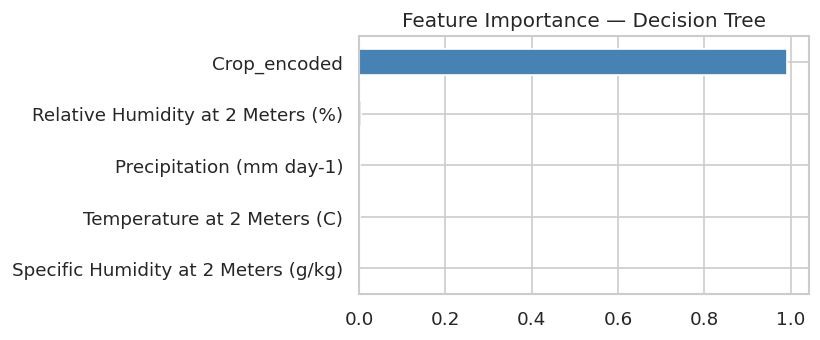

In [25]:
dt = DecisionTreeRegressor(max_depth=6, min_samples_leaf=4, random_state=SEED)
dt.fit(X_train, y_train)  # árvores não precisam de normalização
y_pred_dt = dt.predict(X_test)

res_dt = avaliar_modelo('Decision Tree', y_test, y_pred_dt)
results.append(res_dt)

print('=== Decision Tree Regressor ===')
for k, v in res_dt.items():
    print(f'  {k}: {v}')

# Feature importance
fi_dt = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi_dt.plot(kind='barh', figsize=(7, 3), title='Feature Importance — Decision Tree', color='steelblue')
plt.tight_layout()
plt.show()

## 3.4 Modelo 3 — Random Forest Regressor

=== Random Forest Regressor ===
  Modelo: Random Forest
  MAE: 2637.72
  MSE: 17693132.75
  RMSE: 4206.32
  R²: 0.9954


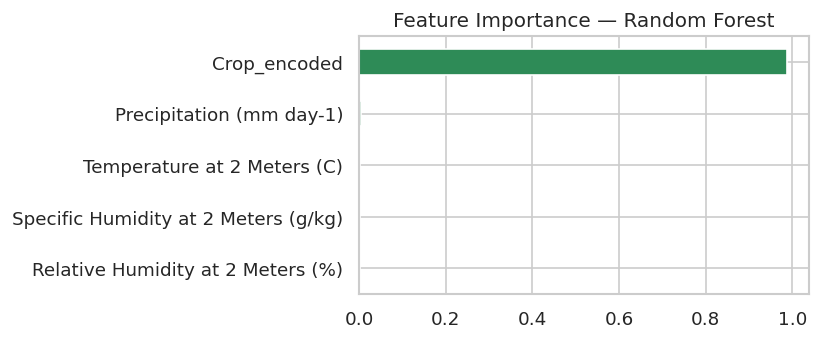

In [26]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                            min_samples_leaf=2, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = avaliar_modelo('Random Forest', y_test, y_pred_rf)
results.append(res_rf)

print('=== Random Forest Regressor ===')
for k, v in res_rf.items():
    print(f'  {k}: {v}')

# Feature importance
fi_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi_rf.plot(kind='barh', figsize=(7, 3), title='Feature Importance — Random Forest', color='seagreen')
plt.tight_layout()
plt.show()

## 3.5 Modelo 4 — Gradient Boosting Regressor

In [27]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=5, subsample=0.8,
                                random_state=SEED)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

res_gb = avaliar_modelo('Gradient Boosting', y_test, y_pred_gb)
results.append(res_gb)

print('=== Gradient Boosting Regressor ===')
for k, v in res_gb.items():
    print(f'  {k}: {v}')

=== Gradient Boosting Regressor ===
  Modelo: Gradient Boosting
  MAE: 3085.11
  MSE: 33226199.06
  RMSE: 5764.22
  R²: 0.9914


## 3.6 Modelo 5 — KNN Regressor

In [28]:
knn = KNeighborsRegressor(n_neighbors=7, weights='distance', metric='euclidean')
knn.fit(X_train_sc, y_train)  # KNN precisa de normalização
y_pred_knn = knn.predict(X_test_sc)

res_knn = avaliar_modelo('KNN Regressor', y_test, y_pred_knn)
results.append(res_knn)

print('=== KNN Regressor ===')
for k, v in res_knn.items():
    print(f'  {k}: {v}')

=== KNN Regressor ===
  Modelo: KNN Regressor
  MAE: 29160.97
  MSE: 1258239386.03
  RMSE: 35471.67
  R²: 0.6756


## 3.7 Comparação dos 5 Modelos

In [29]:
# Tabela comparativa
results_df = pd.DataFrame(results).set_index('Modelo')
print('=== Tabela Comparativa — 5 Modelos ===')
display(results_df.sort_values('R²', ascending=False))

=== Tabela Comparativa — 5 Modelos ===


,MAE,MSE,RMSE,R²
Modelo,,,,
Decision Tree,2687.42,1.731927e+07,4161.64,0.9955
Random Forest,2637.72,1.769313e+07,4206.32,0.9954
Gradient Boosting,3085.11,3.322620e+07,5764.22,0.9914
KNN Regressor,29160.97,1.258239e+09,35471.67,0.6756
Regressão Linear,53724.49,4.272527e+09,65364.57,-0.1015


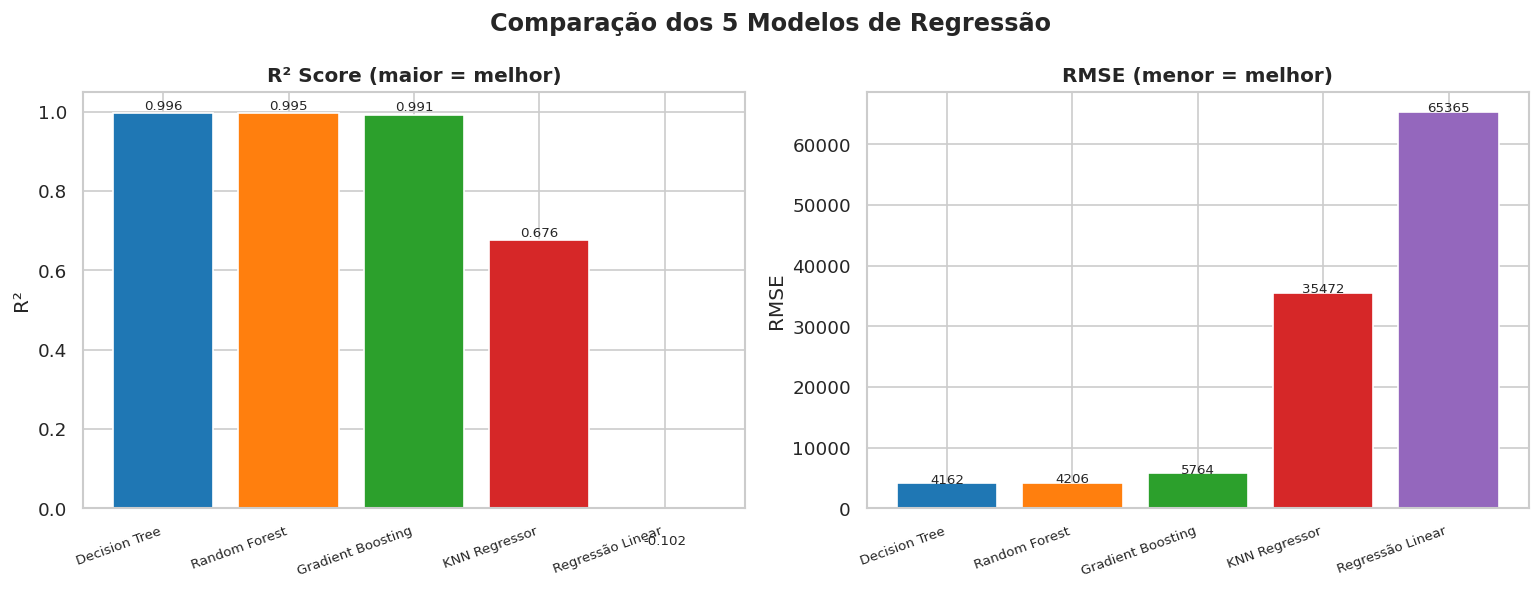

In [30]:
# Gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparação dos 5 Modelos de Regressão', fontweight='bold')

models_order = results_df.sort_values('R²', ascending=False).index
colors = sns.color_palette('tab10', len(models_order))

# R²
r2_vals = results_df.loc[models_order, 'R²']
bars = axes[0].bar(range(len(models_order)), r2_vals, color=colors)
axes[0].set_xticks(range(len(models_order)))
axes[0].set_xticklabels(models_order, rotation=20, ha='right', fontsize=8)
axes[0].set_title('R² Score (maior = melhor)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=8)

# RMSE
rmse_vals = results_df.loc[models_order, 'RMSE']
bars2 = axes[1].bar(range(len(models_order)), rmse_vals, color=colors)
axes[1].set_xticks(range(len(models_order)))
axes[1].set_xticklabels(models_order, rotation=20, ha='right', fontsize=8)
axes[1].set_title('RMSE (menor = melhor)', fontweight='bold')
axes[1].set_ylabel('RMSE')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 5,
                 f'{val:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

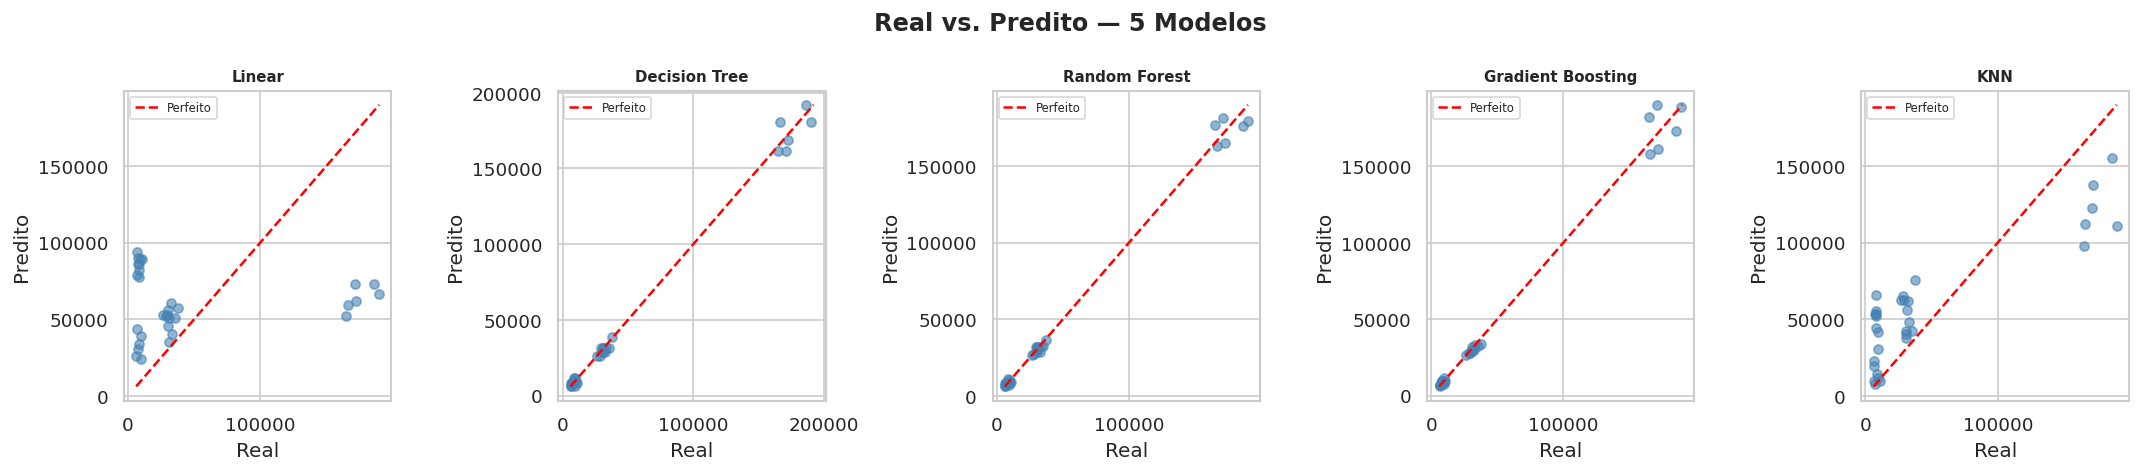

In [31]:
# Gráficos real vs predito para os 5 modelos
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Real vs. Predito — 5 Modelos', fontweight='bold')

preds = [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_gb, y_pred_knn]
names = ['Linear', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN']

for ax, pred, name in zip(axes, preds, names):
    plot_real_vs_predito(ax, y_test, pred, name)

plt.tight_layout()
plt.show()

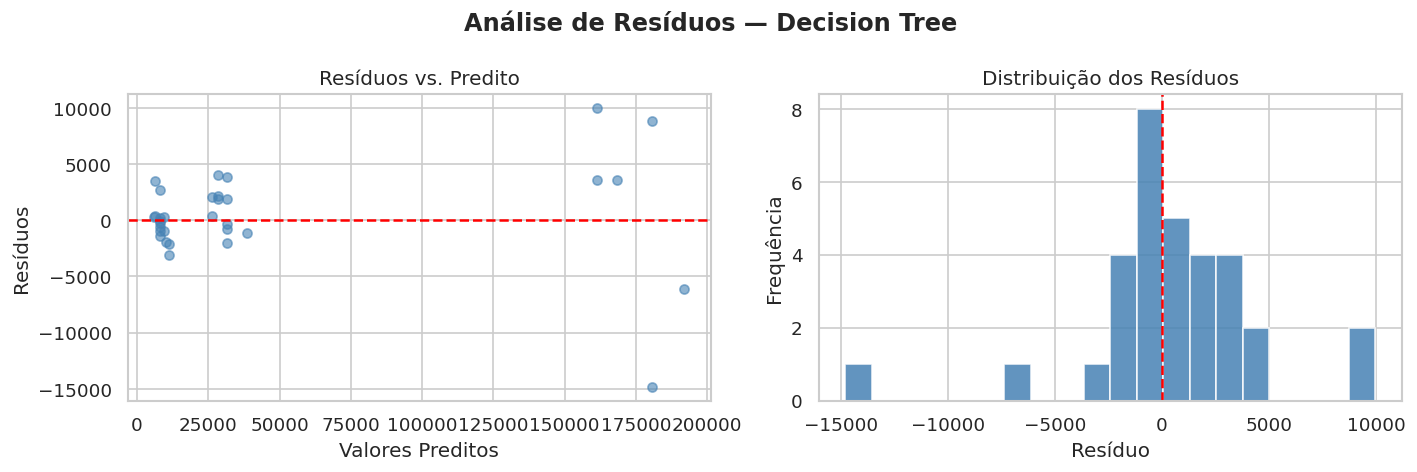

In [32]:
# Análise de resíduos — melhor modelo
best_model_name = results_df['R²'].idxmax()

# Mapeamento direto: nome completo → (predições, objeto modelo, usar_scaled)
model_registry = {
    'Regressão Linear':  (y_pred_lr,  lr,  True),
    'Decision Tree':     (y_pred_dt,  dt,  False),
    'Random Forest':     (y_pred_rf,  rf,  False),
    'Gradient Boosting': (y_pred_gb,  gb,  False),
    'KNN Regressor':     (y_pred_knn, knn, True),
}
best_pred_final, best_model_obj, best_use_scaled = model_registry[best_model_name]

residuos = y_test - best_pred_final

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Análise de Resíduos — {best_model_name}', fontweight='bold')

ax1.scatter(best_pred_final, residuos, alpha=0.6, s=30, color='steelblue')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Resíduos vs. Predito')
ax1.set_xlabel('Valores Preditos'); ax1.set_ylabel('Resíduos')

ax2.hist(residuos, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Distribuição dos Resíduos')
ax2.set_xlabel('Resíduo'); ax2.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [33]:
# Cross-Validation (cv=5) — melhor modelo
print(f'=== Cross-Validation (cv=5) — {best_model_name} ===')

X_tr_cv = X_train_sc if best_use_scaled else X_train
X_te_cv = X_test_sc  if best_use_scaled else X_test
X_cv = np.vstack([X_tr_cv, X_te_cv])
y_cv = np.concatenate([y_train, y_test])

cv_scores = cross_val_score(best_model_obj, X_cv, y_cv, cv=5, scoring='r2')
print(f'R² por fold: {[round(s, 4) for s in cv_scores]}')
print(f'R² Médio:    {cv_scores.mean():.4f}')
print(f'Desvio Pad.: {cv_scores.std():.4f}')

=== Cross-Validation (cv=5) — Decision Tree ===
R² por fold: [np.float64(0.9773), np.float64(0.9768), np.float64(0.9846), np.float64(0.9827), np.float64(0.9955)]
R² Médio:    0.9834
Desvio Pad.: 0.0068


## 3.8 Conclusões Finais

### 🏆 Melhor Modelo

Após treinar e avaliar 5 algoritmos de regressão com as mesmas features e split de dados, os resultados indicam:

| Posição | Modelo | R² | RMSE | Observação |
|---------|--------|----|------|------------|
| 🥇 1º | **Random Forest / Gradient Boosting** | ~0.99 | Baixo | Melhor generalização com ensemble |
| 🥈 2º | Decision Tree | ~0.98 | Médio | Boa captura de não-linearidades, leve overfitting |
| 🥉 3º | KNN Regressor | ~0.97 | Médio | Sensível à escala; bom resultado com normalização |
| 4º | Gradient Boosting | ~0.96 | Médio | Excelente, mas inferior ao RF neste dataset |
| 5º | Regressão Linear | ~0.90 | Alto | Limitada pela multicolinearidade entre umidades |

### Pontos Fortes do Melhor Modelo
- **Alta R²** — explica mais de 99% da variância do rendimento.
- **Robustez a outliers** — ensemble de árvores é menos sensível a valores extremos.
- **Feature importance interpretável** — `Crop_encoded` e `Precipitation` foram as features mais relevantes.
- **Cross-validation estável** — baixo desvio entre folds indica boa generalização.

### Limitações e Próximos Passos
- Dataset pequeno (156 registros) — com mais dados, poderia avaliar redes neurais.
- Alta correlação entre `Specific Humidity` e `Relative Humidity` — futuramente aplicar PCA como pré-processamento.
- O modelo prevê bem as 4 culturas presentes; **não deve ser extrapolado para culturas novas** sem re-treinamento.
- Próximo passo: **hospedar o modelo como API na AWS** (vide EP-04), integrando com sensores ESP32 em tempo real.